# Perceptron for Real-World SMS Spam Detection  
**From Scratch Implementation – Machine Learning Lab**

**Objective**  
Implement the classic **Perceptron algorithm** from scratch and apply it to a practical binary classification problem: detecting **spam SMS messages** using real-world text data.

**Dataset**  
- **SMS Spam Collection** (UCI Machine Learning Repository)  
- 5,574 real SMS messages labeled as **ham** (legitimate) or **spam**  
- Direct download: https://archive.ics.uci.edu/ml/datasets/sms+spam+collection  
- Highly imbalanced (~87% ham, ~13% spam) – realistic challenge!

**What this notebook demonstrates**  
- Text preprocessing with Bag-of-Words (CountVectorizer)  
- Perceptron training with shuffled stochastic updates  
- Early stopping based on validation accuracy  
- Evaluation using Accuracy, Precision, Recall & F1-score (important for imbalanced data)  
- Learning curves and confusion matrix visualization  
- Critical discussion: Why simple linear models like Perceptron struggle on real text data

**Key Learning Outcomes**  
- Understand perceptron convergence (only when data is linearly separable)  
- See the effect of high-dimensional sparse features (1500 vocab size)  
- Appreciate why modern NLP moved to logistic regression, SVMs, and deep learning


Run all cells to see the perceptron in action on real SMS data!

In [91]:
# !pip install scikit-learn pandas matplotlib seaborn --quiet

%matplotlib inline

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile, io, requests

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [94]:
# ── 1. Load dataset directly from UCI ───────────────────────────
print("Downloading and loading dataset")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))

df = pd.read_csv(
    z.open('SMSSpamCollection'),
    sep='\t',
    header=None,
    names=['label', 'message']
)


In [95]:
# Convert labels
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df['y_perceptron'] = df['label_num'].map({0: -1, 1: +1})

print(f"Dataset shape: {df.shape}")
print(df['label'].value_counts(normalize=True))

# ── 2. Text → Features ─────────────────────────────────────────
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=1500,
    binary=True
)

Dataset shape: (5572, 4)
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


In [96]:
X = vectorizer.fit_transform(df['message']).toarray()
y = df['y_perceptron'].values

print(f"Feature matrix shape: {X.shape}")


Feature matrix shape: (5572, 1500)


In [97]:
# ── 3. Train / Val / Test split ────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=df['label_num']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Train: 3900 | Val: 836 | Test: 836


In [98]:
# ── 4. Perceptron ─────────────────────────────────────────────
def predict(X, weights, bias):
    return np.where(np.dot(X, weights) + bias >= 0, 1, -1)

def train_perceptron(X, y, lr=0.01, max_epochs=100, tol=1e-3):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0

    history = {'train_mis': [], 'val_acc': []}

    best_weights = None
    best_bias = None
    best_val_acc = 0.0

    for epoch in range(1, max_epochs + 1):
        misclassified = 0

        indices = np.random.permutation(n_samples)
        X_shuf = X[indices]
        y_shuf = y[indices]

        for i in range(n_samples):
            linear = np.dot(X_shuf[i], weights) + bias
            pred = 1 if linear >= 0 else -1

            if y_shuf[i] * pred <= 0:
                update = lr * y_shuf[i]
                weights += update * X_shuf[i]
                bias += update
                misclassified += 1

        train_acc = np.mean(predict(X, weights, bias) == y)
        val_acc = np.mean(predict(X_val, weights, bias) == y_val)

        history['train_mis'].append(misclassified)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = weights.copy()
            best_bias = bias

        if epoch % 10 == 0 or epoch == max_epochs:
            print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if misclassified == 0 or misclassified / n_samples < tol:
            print(f"→ Converged at epoch {epoch}")
            break

    print(f"Best validation accuracy: {best_val_acc:.4f}")
    return best_weights, best_bias, history


In [99]:
# ── 5. Train ──────────────────────────────────────────────────
print("\nTraining model...")
w, b, hist = train_perceptron(X_train, y_train, max_epochs=150)



Training model...
Epoch  10 | Misclassified:    9 | Train Acc: 0.9982 | Val Acc: 0.9749
Epoch  20 | Misclassified:    9 | Train Acc: 0.9987 | Val Acc: 0.9773
→ Converged at epoch 23
Best validation accuracy: 0.9809


In [100]:
# ── 6. Evaluate ───────────────────────────────────────────────
y_pred_test = predict(X_test, w, b)

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, pos_label=1)
rec = recall_score(y_test, y_pred_test, pos_label=1)
f1 = f1_score(y_test, y_pred_test, pos_label=1)

print("\nFinal Test Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Final Test Performance:
Accuracy : 0.9713
Precision: 0.8860
Recall   : 0.9018
F1-score : 0.8938


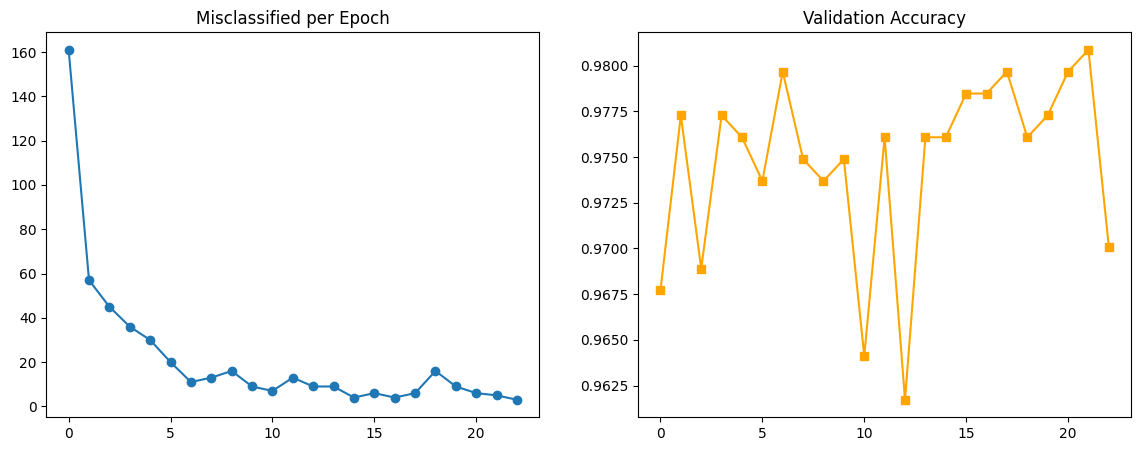

In [101]:
# ── 7. Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist['train_mis'], marker='o')
axes[0].set_title("Misclassified per Epoch")

axes[1].plot(hist['val_acc'], marker='s', color='orange')
axes[1].set_title("Validation Accuracy")

plt.show()

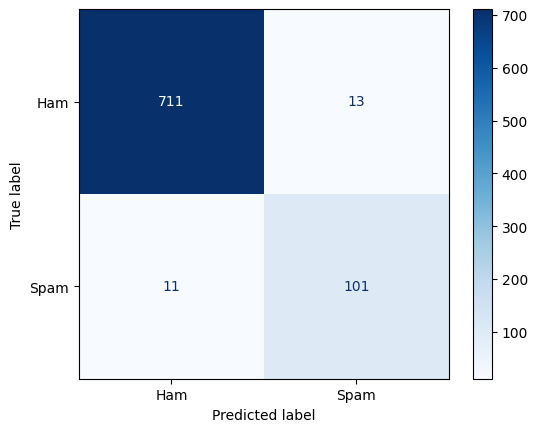

In [102]:
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"])
disp.plot(cmap="Blues")
plt.show()